**BANCO DE DADOS**

Dados analisados são parte de estudo transversal realizado em um hospital público do município de São Paulo, que teve como um dos objetivos identificar os fatores determinantes da prática de atividade física nos últimos 12 meses. A amostra é composta por 150 homens com 50 anos ou mais (disponíveis no arquivo “Atividadefísica.xls”).

As variáveis disponibilizadas no banco de dados são:

• id: número de identificação do indivíduo;

• escore: escore de prática de atividade física nos últimos 12 meses (quanto maior,maior a prática);

• idade, em anos;

• renda, em reais;

• escol: escolaridade, em anos de estudo (0: até 3, 1: mais de 3).

• IMC

In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

In [2]:
# Técnicas de redução de dimensionalidade:
# TSNE (t-SNE) e PCA (Análise de Componentes Principais)
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

# Modelos de regressão:
from sklearn.linear_model import LinearRegression  # Regressão Linear
from sklearn.tree import DecisionTreeRegressor     # Regressão por Árvore de Decisão
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor  # Modelos de Ensemble: Floresta Aleatória e Gradient Boosting
from sklearn.neighbors import KNeighborsRegressor   # Regressão baseada em Vizinhos Mais Próximos (KNN)

# Ferramentas para divisão dos dados e validação cruzada:
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict
# - train_test_split: divide os dados em conjuntos de treino e teste
# - cross_val_score: avalia o modelo usando validação cruzada
# - cross_val_predict: gera predições usando validação cruzada

# Métricas de avaliação de modelos de regressão:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# - mean_absolute_error (MAE): erro absoluto médio
# - mean_squared_error (MSE): erro quadrático médio
# - r2_score (R²): coeficiente de determinação

# Bibliotecas auxiliares:
import numpy as np              # Manipulação de arrays e operações numéricas
import pandas as pd             # Manipulação de dados em DataFrames
import matplotlib.pyplot as plt # Criação de gráficos e visualizações

In [3]:
# df_dados = pd.read_excel('/content/drive/MyDrive/Ciências Atuariais 2025_2/ANÁLISE DE REGRESSÃO I/Atividade_fisica_com_IMC.xlsx')
df_dados = pd.read_excel('downloads/Atividade_fisica_com_IMC.xlsx', index_col='id')

In [4]:
df_dados

,escore,idade,renda,escol,IMC
id,,,,,
1,9.375,64,313.0,1,23.386088
2,6.000,69,301.2,0,25.722428
3,6.875,47,270.1,0,23.303894
4,7.750,54,285.4,1,23.429262
5,9.125,51,250.0,1,23.284418
...,...,...,...,...,...
146,6.875,73,310.5,0,24.170127
147,5.375,56,230.9,0,24.801692
148,7.375,80,256.3,1,23.892045


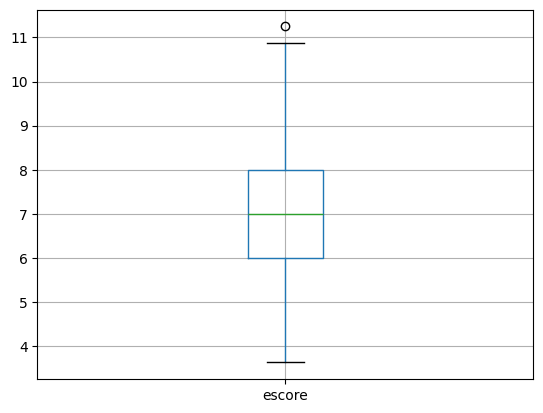

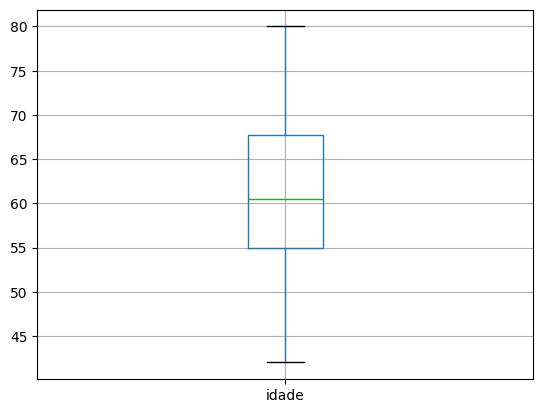

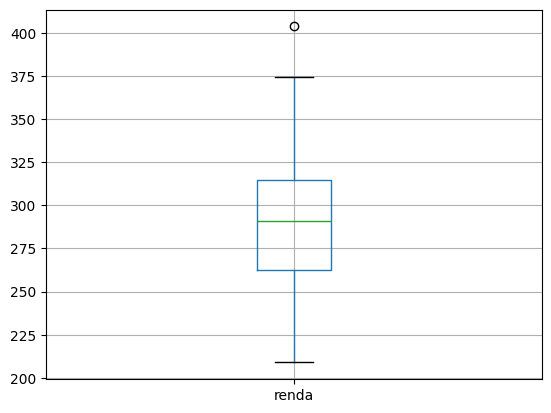

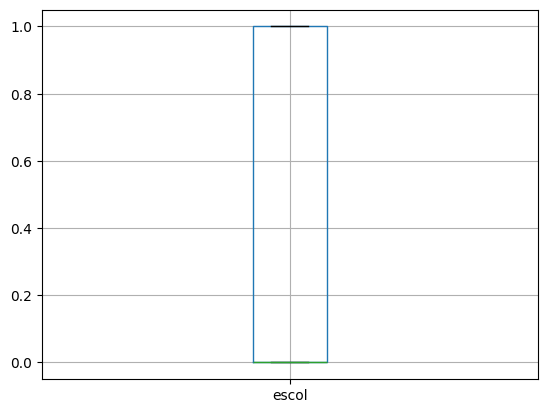

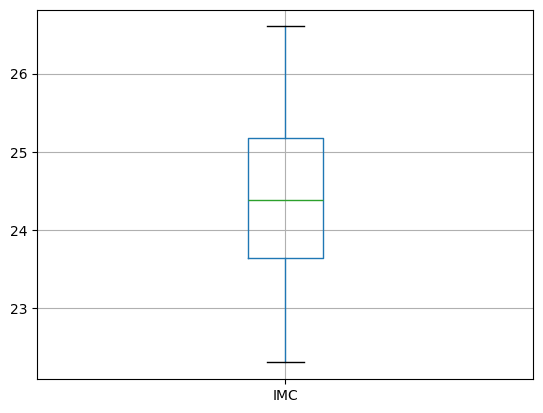

In [5]:
# df_dados = df_dados.drop('id', axis=1)
for col in df_dados.columns:
    df_dados[[col]].boxplot()
    plt.show()

In [6]:
df_dados.describe()

,escore,idade,renda,escol,IMC
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,7.031667,61.726667,289.047333,0.480000,24.408054
std,1.423908,8.402538,35.537919,0.501274,1.081755
min,3.625000,42.000000,208.900000,0.000000,22.305665
25%,6.000000,55.000000,262.575000,0.000000,23.639899
50%,7.000000,60.500000,291.100000,0.000000,24.385978
75%,8.000000,67.750000,314.600000,1.000000,25.169463
max,11.250000,80.000000,403.700000,1.000000,26.601764


In [7]:
# Correlação e heatmap
import seaborn as sns

sns.heatmap(
    data=df_dados.corr(),
    cmap='vlag',
    annot=True,
    vmin=-1,
    vmax=1,
)
df_dados.describe()

,escore,idade,renda,escol,IMC
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,7.031667,61.726667,289.047333,0.480000,24.408054
std,1.423908,8.402538,35.537919,0.501274,1.081755
min,3.625000,42.000000,208.900000,0.000000,22.305665
25%,6.000000,55.000000,262.575000,0.000000,23.639899
50%,7.000000,60.500000,291.100000,0.000000,24.385978
75%,8.000000,67.750000,314.600000,1.000000,25.169463
max,11.250000,80.000000,403.700000,1.000000,26.601764


In [8]:
sns.pairplot(
    data=df_dados,
    hue='escol',
)

In [9]:
#=============================================================================
# SEPARAÇÃO DAS FEATURES (ENTRADAS) E DO TARGET (SAÍDA)
# =============================================================================

# Extrai a variável de saída (target) como um array
target = df_dados['escore'].values

# Remove a coluna 'target' para obter apenas as variáveis preditoras
df_features = df_dados.drop(columns=['escore'])
# df_features = df_dados[['IMC', 'idade']]

# Exibe o DataFrame com as features (atributos preditores)
df_features


,idade,renda,escol,IMC
id,,,,
1,64,313.0,1,23.386088
2,69,301.2,0,25.722428
3,47,270.1,0,23.303894
4,54,285.4,1,23.429262
5,51,250.0,1,23.284418
...,...,...,...,...
146,73,310.5,0,24.170127
147,56,230.9,0,24.801692
148,80,256.3,1,23.892045


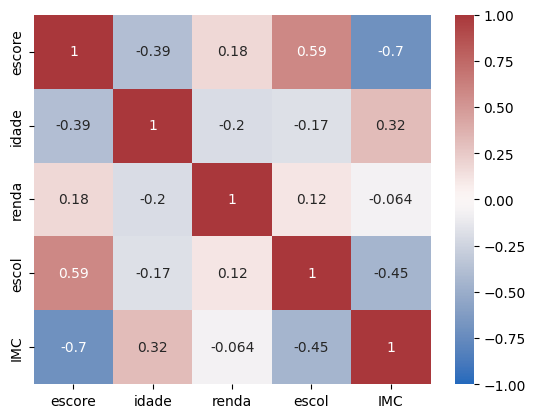

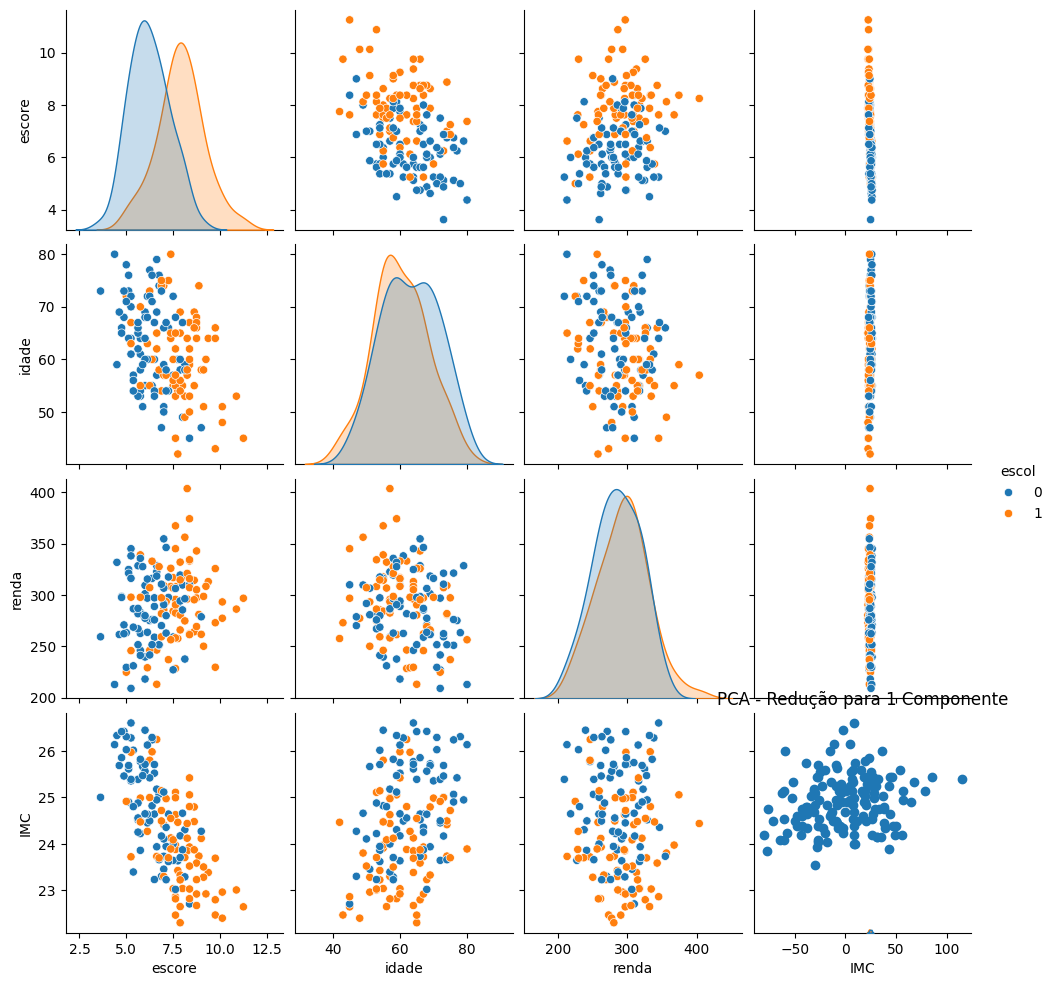

In [10]:
# =============================================================================
# REDUÇÃO DE DIMENSIONALIDADE COM PCA E VISUALIZAÇÃO
# =============================================================================

# Aplica PCA para reduzir os dados a 1 componente principal
pca = PCA(n_components=1)
array_red_pca = pca.fit_transform(df_features.values)

# Cria o gráfico de dispersão entre PC1 e o alvo (target)
plt.scatter(array_red_pca, target)
plt.title('PCA - Redução para 1 Componente')
plt.xlabel('Componente Principal 1 (PC1)')
plt.ylabel('Target (Escores)')
#plt.grid(True)
plt.show()

In [11]:
# =============================================================================
# DEFINIÇÃO DAS VARIÁVEIS DE ENTRADA (X) E SAÍDA (y)
# =============================================================================

# Converte o DataFrame de features (atributos preditores) para array NumPy
# feature_columns = ['IMC', 'idade']
feature_columns = ['IMC', 'idade', 'renda', 'escol']
# feature_columns = ['IMC', 'escol']
X = df_features[feature_columns].values

# Já havíamos definido 'target' como a variável de saída (alvo), associada à progressão da doença
y = target

In [18]:
# =============================================================================
# FUNÇÃO PARA RETORNAR O MODELO DE REGRESSÃO ESCOLHIDO
# Basta descomentar a linha correspondente ao modelo desejado
# =============================================================================
def getModel():
    # return LinearRegression()              # Regressão Linear
    from sklearn.pipeline import make_pipeline
    from sklearn.preprocessing import StandardScaler
    return make_pipeline(StandardScaler(), GradientBoostingRegressor())
    # return DecisionTreeRegressor()         # Árvore de Decisão
    # return RandomForestRegressor()         # Floresta Aleatória (Bagging)
    # return GradientBoostingRegressor()       # Boosting Gradiente (modelo ativo)
    # return KNeighborsRegressor()           # k-Vizinhos Mais Próximos


In [19]:
# =============================================================================
# TREINAMENTO E AVALIAÇÃO SIMPLES COM REGRESSOR ESCOLHIDO
# =============================================================================

# Divide os dados em treino (80%) e teste (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Obtém o modelo selecionado e treina com os dados de treino
model = getModel().fit(X_train, y_train)

# Avalia o modelo nos dados de teste com a métrica R²
r2 = model.score(X_test, y_test)

# Exibe o R²: mede o quanto o modelo explica da variância do target
print(f"Coeficiente de Determinação (R²): {r2:.4f}")
model

Coeficiente de Determinação (R²): 0.4183


,steps,"[('standardscaler', ...), ('gradientboostingregressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0


In [20]:
# =============================================================================
# AVALIAÇÃO DO DESEMPENHO DO MODELO NO CONJUNTO DE TESTE
# =============================================================================

# Fazer previsões no conjunto de teste
y_pred = model.predict(X_train)

# Calcular métricas de erro
mae = mean_absolute_error(y_train, y_pred)        # Erro Médio Absoluto
mse = mean_squared_error(y_train, y_pred)         # Erro Quadrático Médio
r2 = r2_score(y_train, y_pred)                    # Coeficiente de Determinação (R²)

# Exibir os resultados
print("Avaliação do Modelo no Conjunto de Treino:")
print(f"MAE (Erro Médio Absoluto): {mae:.2f}")
print(f"MSE (Erro Quadrático Médio): {mse:.2f}")
print(f"R² (Coeficiente de Determinação): {r2:.4f}")

Avaliação do Modelo no Conjunto de Treino:
MAE (Erro Médio Absoluto): 0.29
MSE (Erro Quadrático Médio): 0.13
R² (Coeficiente de Determinação): 0.9404


In [21]:
# =============================================================================
# AVALIAÇÃO DO DESEMPENHO DO MODELO NO CONJUNTO DE TESTE
# =============================================================================

# Fazer previsões no conjunto de teste
y_pred = model.predict(X_test)

# Calcular métricas de erro
mae = mean_absolute_error(y_test, y_pred)        # Erro Médio Absoluto
mse = mean_squared_error(y_test, y_pred)         # Erro Quadrático Médio
r2 = r2_score(y_test, y_pred)                    # Coeficiente de Determinação (R²)

# Exibir os resultados
print("Avaliação do Modelo no Conjunto de Teste:")
print(f"MAE (Erro Médio Absoluto): {mae:.2f}")
print(f"MSE (Erro Quadrático Médio): {mse:.2f}")
print(f"R² (Coeficiente de Determinação): {r2:.4f}")


Avaliação do Modelo no Conjunto de Teste:
MAE (Erro Médio Absoluto): 0.67
MSE (Erro Quadrático Médio): 0.81
R² (Coeficiente de Determinação): 0.4183


**O que fazer ?**

Train sizes: [ 15.  30.  45.  60.  75.  90. 105. 120. 135. 150.]


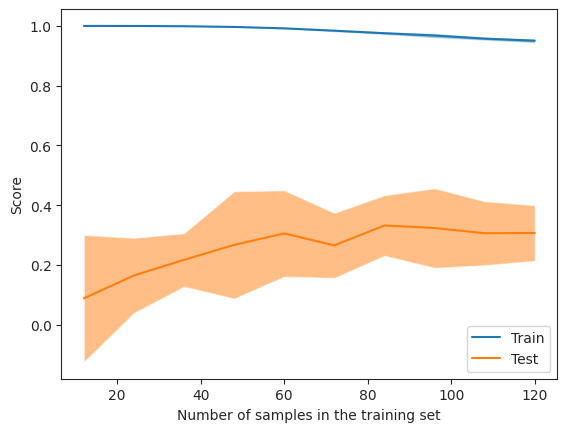

In [26]:
import seaborn as sns
from sklearn.model_selection import LearningCurveDisplay, ValidationCurveDisplay

sns.set_style('ticks')

train_sizes = np.linspace(0.1, 1.0, 10)
print(f'Train sizes: {train_sizes * 150}')
LearningCurveDisplay.from_estimator(
    estimator=getModel(),
    X=X,
    y=y,
    shuffle=True,
    # n_jobs=2,
    # std_display_style='errorbar',
    random_state=0,
    train_sizes=train_sizes
)
plt.show()

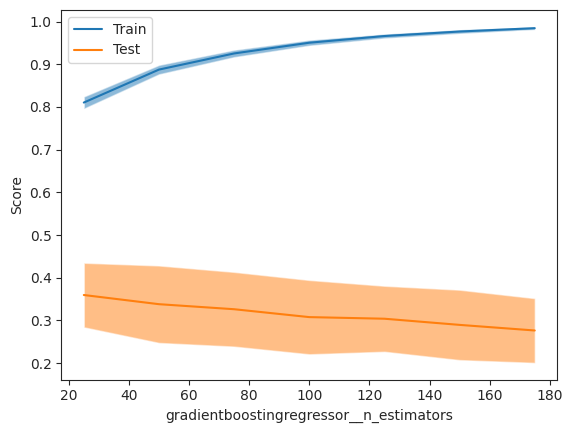

In [27]:
from sklearn.pipeline import Pipeline


param_name, param_range = None, None

validation_model = getModel()

if isinstance(validation_model, (GradientBoostingRegressor)):
    # overfitting
    param_name = 'n_estimators'
    param_range = [25, 50, 100, 200, 400]
elif isinstance(validation_model, Pipeline):
    param_name = 'gradientboostingregressor__n_estimators'
    param_range = [25, 50, 75, 100, 125, 150, 175]
elif isinstance(validation_model, KNeighborsRegressor):
    # underfitting
    param_name = 'leaf_size'
    param_range = [10, 15, 30, 45, 60]

if param_name is not None:
    ValidationCurveDisplay.from_estimator(
        estimator=validation_model,
        param_name=param_name,
        param_range=param_range,
        X=X,
        y=y,
        cv=5
    )
    plt.show()

### Curva de validação

Análise da cuva de validação

|   score   |  test baixo  | test alto |
|:---------:|:------------:|:---------:|
|train baixo|_underfitting_| impossivel|
| train alto|_overfitting_ | muito bom |